# Machine Learning Project
## Part 1: Data Exploration and Preprocessing for the Bank Marketing Dataset
**Prepared by:** Zaid Moen  
**Course:** Machine Learning  
**Dataset:** `bank.csv`

### Objective
In this part, the goal is to understand the structure of the dataset, assess its quality, identify useful patterns, and prepare a clean feature matrix for the next stages of the project.

### 1. Library Setup
The following libraries are used for data handling, visualization, and preprocessing.

In [1]:
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

### 2. Loading the Dataset
First, the dataset is loaded and checked to confirm its size and general structure.

In [2]:
df = pd.read_csv("bank.csv")

print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

df.head()

Rows: 11162
Columns: 17


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [3]:
سoverview = pd.DataFrame(
    {
        "data_type": df.dtypes.astype(str),
        "non_null_count": df.notna().sum(),
        "unique_values": df.nunique()
    }
)

overview

,data_type,non_null_count,unique_values
age,int64,11162,76
job,str,11162,12
marital,str,11162,3
education,str,11162,4
default,str,11162,2
balance,int64,11162,3805
housing,str,11162,2
loan,str,11162,2
contact,str,11162,3
day,int64,11162,31


### 3. Data Quality Checks
Before moving to modeling, it is important to verify whether the dataset contains missing values or duplicated observations.

In [4]:
missing_values = df.isna().sum().sort_values(ascending=False)
duplicates = df.duplicated().sum()

quality_report = pd.DataFrame(
    {
        "missing_values": missing_values,
        "missing_percentage": (missing_values / len(df) * 100).round(2)
    }
)

print(f"Duplicate rows: {duplicates}")
quality_report

Duplicate rows: 0


,missing_values,missing_percentage
age,0,0.0
job,0,0.0
marital,0,0.0
education,0,0.0
default,0,0.0
balance,0,0.0
housing,0,0.0
loan,0,0.0
contact,0,0.0
day,0,0.0


### Initial Quality Notes
The dataset is already in strong condition for machine learning work:
- no missing values were detected,
- no duplicated rows were found,
- the target column is available for all records.

This allows the preprocessing stage to focus on proper encoding, scaling, and splitting rather than repairing corrupted data.

### 4. Exploratory Data Analysis (EDA)
This section highlights the main numerical and categorical patterns that are useful before training any model.

In [5]:
df[["age", "balance", "day", "duration", "campaign", "pdays", "previous"]].describe().round(2)

,age,balance,day,duration,campaign,pdays,previous
count,11162.00,11162.00,11162.00,11162.00,11162.00,11162.00,11162.00
mean,41.23,1528.54,15.66,371.99,2.51,51.33,0.83
std,11.91,3225.41,8.42,347.13,2.72,108.76,2.29
min,18.00,-6847.00,1.00,2.00,1.00,-1.00,0.00
25%,32.00,122.00,8.00,138.00,1.00,-1.00,0.00
50%,39.00,550.00,15.00,255.00,2.00,-1.00,0.00
75%,49.00,1708.00,22.00,496.00,3.00,20.75,1.00
max,95.00,81204.00,31.00,3881.00,63.00,854.00,58.00


deposit
no     52.62
yes    47.38
Name: percentage, dtype: float64


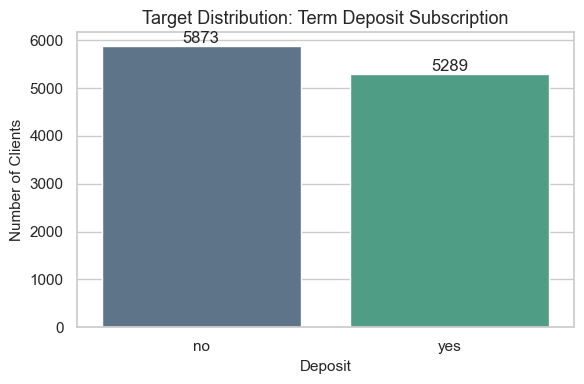

In [6]:
target_share = (df["deposit"].value_counts(normalize=True).reindex(["no", "yes"]) * 100).round(2)
print(target_share.rename("percentage"))

fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=df, x="deposit", order=["no", "yes"], palette=["#577590", "#43aa8b"], ax=ax)
ax.set_title("Target Distribution: Term Deposit Subscription")
ax.set_xlabel("Deposit")
ax.set_ylabel("Number of Clients")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

The target is reasonably balanced: around 52.6% of clients did not subscribe to a deposit, while 47.4% did. This is helpful because it lowers the risk of a model learning a trivial majority-class prediction.

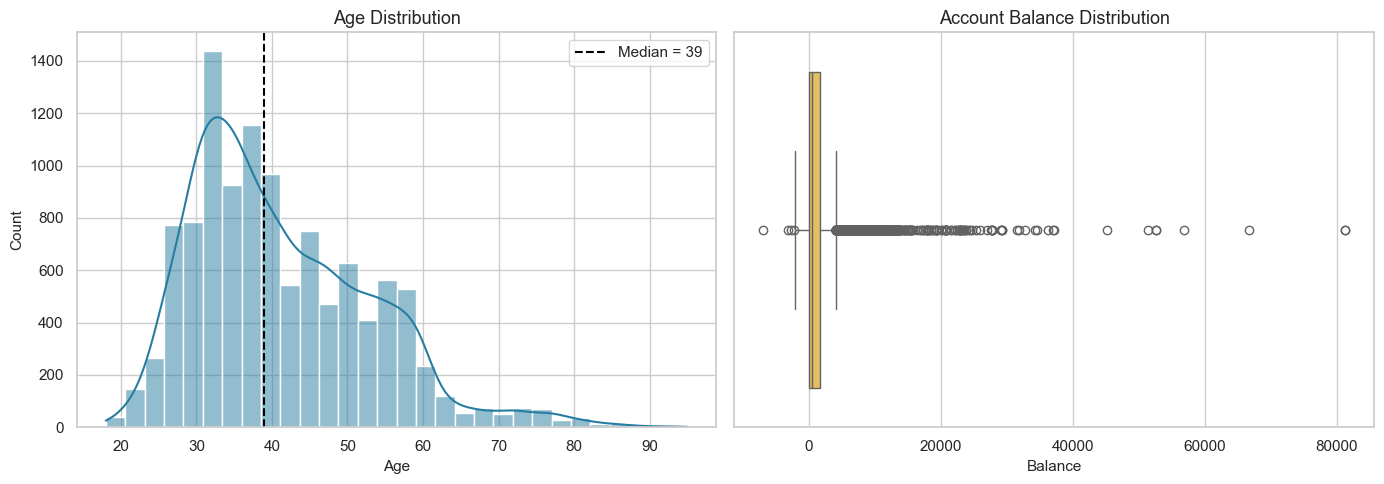

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["age"], bins=30, kde=True, color="#277da1", ax=axes[0])
axes[0].axvline(df["age"].median(), color="black", linestyle="--", label=f"Median = {df['age'].median():.0f}")
axes[0].set_title("Age Distribution")
axes[0].set_xlabel("Age")
axes[0].legend()

sns.boxplot(x=df["balance"], color="#f9c74f", ax=axes[1])
axes[1].set_title("Account Balance Distribution")
axes[1].set_xlabel("Balance")

plt.tight_layout()
plt.show()

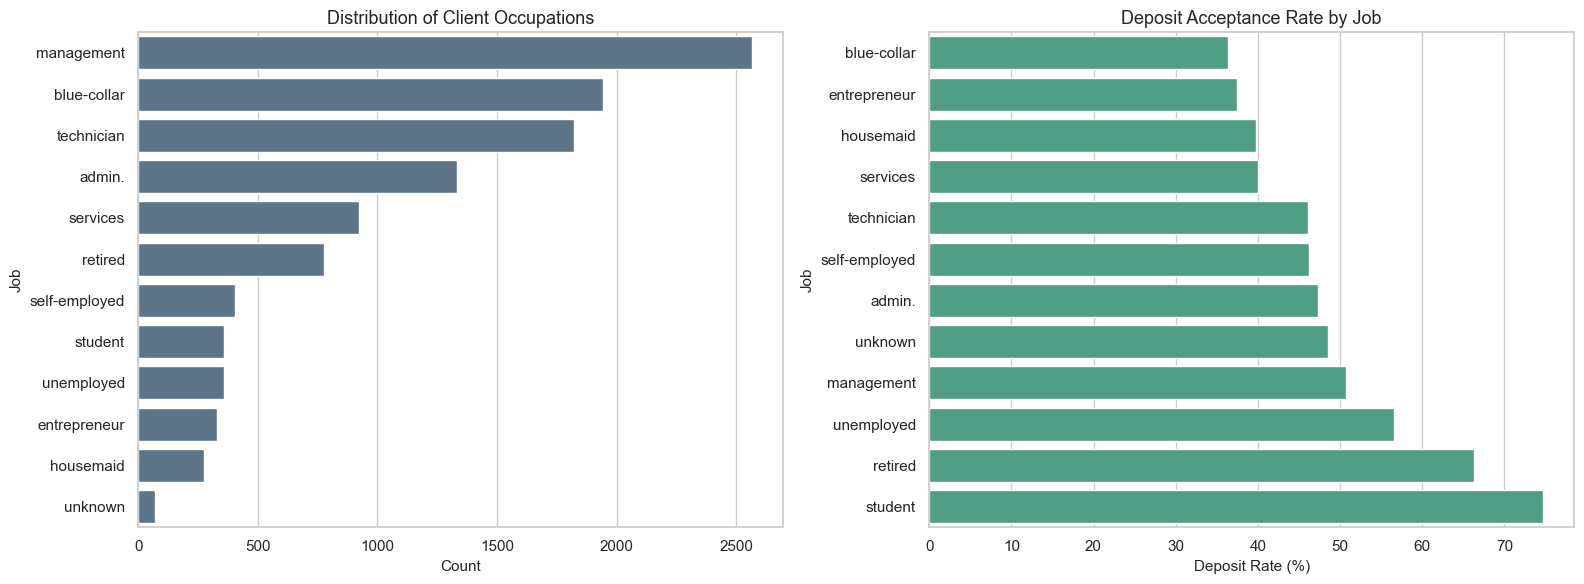

In [8]:
job_order = df["job"].value_counts().index
job_success_rate = (
    df.groupby("job")["deposit"]
      .apply(lambda values: (values == "yes").mean() * 100)
      .sort_values()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.countplot(data=df, y="job", order=job_order, color="#577590", ax=axes[0])
axes[0].set_title("Distribution of Client Occupations")
axes[0].set_xlabel("Count")
axes[0].set_ylabel("Job")

sns.barplot(x=job_success_rate.values, y=job_success_rate.index, color="#43aa8b", ax=axes[1])
axes[1].set_title("Deposit Acceptance Rate by Job")
axes[1].set_xlabel("Deposit Rate (%)")
axes[1].set_ylabel("Job")

plt.tight_layout()
plt.show()

### Key Observations
- The dataset contains 11,162 records and 17 columns, which is a good size for a course project.
- No missing values or duplicated records were found, so the data is structurally clean.
- Numerical variables such as `balance` and `duration` are skewed and include outliers, which supports scaling before modeling.
- The most common occupations are `management`, `blue-collar`, and `technician`.
- Occupation appears to carry predictive value because the deposit acceptance rate differs noticeably across job categories.

### 5. Preprocessing Strategy
To prepare the data for later machine learning tasks, the following decisions are applied:
1. Encode the target variable `deposit` as 0/1.
2. Apply one-hot encoding to categorical input features instead of label encoding, because most categories are nominal and do not have a natural order.
3. Scale only the numerical columns using `StandardScaler`.
4. Use a stratified 80/20 train-test split to preserve class balance in both sets.

In [9]:
X = df.drop("deposit", axis=1).copy()
y = df["deposit"].map({"no": 0, "yes": 1})

categorical_cols = X.select_dtypes(include="object").columns.tolist()
numeric_cols = X.select_dtypes(include=np.number).columns.tolist()

X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print(f"Number of numerical features: {len(numeric_cols)}")
print(f"Number of categorical features: {len(categorical_cols)}")
print(f"Encoded feature matrix shape: {X_encoded.shape}")

X_encoded.head()

Number of numerical features: 7
Number of categorical features: 9
Encoded feature matrix shape: (11162, 42)


,age,balance,day,duration,campaign,pdays,previous,job_blue-collar,job_entrepreneur,job_housemaid,...,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown
0,59,2343,5,1042,1,-1,0,False,False,False,...,False,False,False,True,False,False,False,False,False,True
1,56,45,5,1467,1,-1,0,False,False,False,...,False,False,False,True,False,False,False,False,False,True
2,41,1270,5,1389,1,-1,0,False,False,False,...,False,False,False,True,False,False,False,False,False,True
3,55,2476,5,579,1,-1,0,False,False,False,...,False,False,False,True,False,False,False,False,False,True
4,54,184,5,673,2,-1,0,False,False,False,...,False,False,False,True,False,False,False,False,False,True


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

print(f"Training set shape: {X_train_scaled.shape}")
print(f"Testing set shape: {X_test_scaled.shape}")

Training set shape: (8929, 42)
Testing set shape: (2233, 42)


In [11]:
split_summary = pd.DataFrame(
    {
        "train_%": (y_train.value_counts(normalize=True).sort_index() * 100).round(2),
        "test_%": (y_test.value_counts(normalize=True).sort_index() * 100).round(2)
    }
)

split_summary.index = ["No Deposit (0)", "Deposit (1)"]
split_summary

,train_%,test_%
No Deposit (0),52.62,52.62
Deposit (1),47.38,47.38


## Part 1 Summary
Part 1 produced a clean and model-ready dataset. The analysis confirmed that the bank marketing data is complete, reasonably balanced, and rich in categorical information. After exploring the data, the input variables were encoded appropriately, the numerical features were standardized, and the data was split into stratified training and testing sets.

These outputs can now be used directly in the next parts of the project for clustering, classification, and performance evaluation.